# PCA from Scratch Demo (UCI Seeds Dataset)

In this notebook, we demonstrate the capabilities of a custom PCA implementation built from scratch using eigen-decomposition.

We will use the **UCI Seeds dataset**, which contains measurements of wheat kernels from 3 different varieties.

PCA will be used to:
- Reduce 7-dimensional feature space to 2 dimensions
- Visualize class structure
- Measure explained variance
- Reconstruct original data from reduced representation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset from UCI repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt"

columns = [
    "area", "perimeter", "compactness", "kernel_length",
    "kernel_width", "asymmetry_coefficient", "groove_length", "class"
]

df = pd.read_csv(url, sep=r"\s+", header=None, names=columns)

df.head()

,area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coefficient,groove_length,class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


# Dataset Overview

The Seeds dataset contains 210 samples with 7 numerical features:

- geometric properties of wheat kernels
- 3 classes representing different wheat varieties

We separate features (X) and labels (y) for PCA analysis.

In [2]:
X = df.drop("class", axis=1).values
y = df["class"].values

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (210, 7)
Shape of y: (210,)


# Feature Standardization

PCA is sensitive to feature scaling because it relies on variance.

We standardize features to:
- mean = 0
- variance = 1
before applying PCA.

In [3]:
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)

X_scaled = (X - X_mean) / X_std

# Applying Custom PCA

We now apply the PCA implementation from scratch.

We reduce the dataset from 7 dimensions → 2 dimensions for visualization.

In [4]:
from rice_ml import PCA

pca = PCA(num_components=2)
X_reduced = pca.fit_project(X_scaled)

print("Reduced shape:", X_reduced.shape)

Reduced shape: (210, 2)


# Explained Variance

We examine how much variance is captured by each principal component.

This helps us understand how much information is preserved after dimensionality reduction.

In [5]:
print("Explained variance ratio:", pca.var_ratio_)
print("Total variance captured:", np.sum(pca.var_ratio_))

Explained variance ratio: [0.71874303 0.17108184]
Total variance captured: 0.8898248618491238


# 2D PCA Visualization

We project the dataset into 2D and visualize class separation.

Each point represents a wheat sample.
Colors represent true class labels.

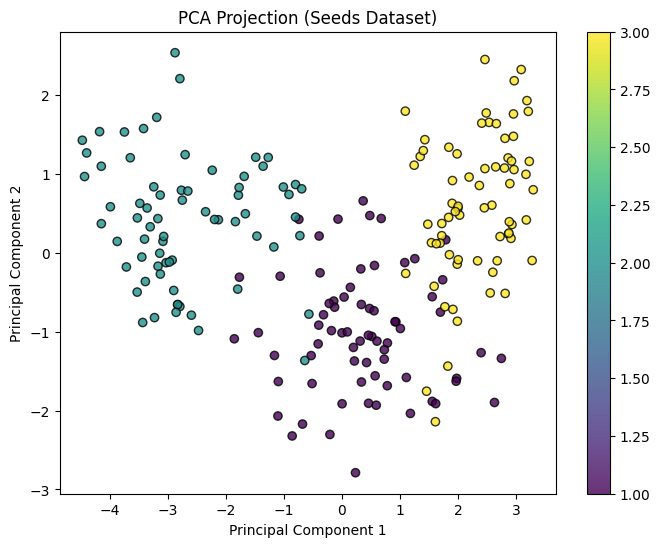

In [6]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    c=y,
    cmap="viridis",
    edgecolor="k",
    alpha=0.8
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection (Seeds Dataset)")
plt.colorbar(scatter)
plt.show()

# Data Reconstruction

We now test how well PCA preserves information by:

1. Projecting data into 2D
2. Reconstructing back to 7D space
3. Measuring reconstruction error

In [7]:
X_reconstructed = pca.reconstruct(X_reduced)

reconstruction_error = np.mean((X_scaled - X_reconstructed) ** 2)

print("Mean Squared Reconstruction Error:", reconstruction_error)

Mean Squared Reconstruction Error: 0.11017513815087648


# Interpretation

- PCA successfully reduces dimensionality while preserving structure
- The first two components capture most variance
- Class separation is partially visible in 2D space
- Reconstruction error shows information loss from compression

This demonstrates PCA as both:
- A visualization tool
- A lossy compression technique